# EMEP PM2.5 measurements
This notebook will read PM2.5 measurements from different EMEP stations and save the data in one file along with station information (i.e. coordinates, altitude).

EMEP data was downloaded from the EBAS database, selecting framework=EMEP, component=pm25_mass and matrix=pm25. I also selected instrument=high_vol_sampler and low_vol_sampler, this was mostly a somewhat arbitrary way to cut down the number of results.


In [2]:
import pandas as pd
import datetime as dt
import re
import xarray as xr
from glob import glob
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs


## functions

In [9]:
def parse_ebas_file(filepath):
    metadata = {}
    data_lines = []

    with open(filepath, "r", encoding="utf-8") as f:
        lines = f.readlines()

    # metadata
    start_idx = int(lines[0].split(" ")[0])
    for line in lines:
        if line.startswith("Station name:"):
            metadata["station_name"] = line.split(":", 1)[1].strip()
        elif line.startswith("Station latitude:"):
            metadata["lat"] = float(line.split(":", 1)[1].strip())
        elif line.startswith("Station longitude:"):
            metadata["lon"] = float(line.split(":", 1)[1].strip())
        elif line.startswith("Station altitude:"):
            # find and save altitude without units
            metadata["altitude_m"] = float(re.findall(r"[-+]?\d*\.\d+|\d+", line)[0])
        elif line.lower().startswith("starttime"):
            # header for data block found
            start_idx = lines.index(line) + 1
            break

    # time reference point
    for line in lines:
        parts = line.strip().split()
        if len(parts) == 6 and all(p.isdigit() for p in parts):
            # Format: YYYY MM DD YYYY MM DD
            ref_date = dt.datetime.strptime(" ".join(parts[:3]), "%Y %m %d")
            break

    # data block
    data = []
    for line in lines[start_idx:]:
        if not line.strip():
            continue
        try:
            start_day, end_day, value, flag = line.split()
            start_dt = ref_date + dt.timedelta(days=float(start_day))
            end_dt = ref_date + dt.timedelta(days=float(end_day))
            data.append([start_dt, end_dt, float(value), float(flag)])
        except ValueError:
            # probably footer text
            break

    df = pd.DataFrame(data, columns=["start_time", "end_time", "pm25", "flag"])
    return metadata, df


def read_stations(filepaths, freq="1D"):
    station_datasets = []

    for fp in filepaths:
        metadata, df = parse_ebas_file(fp)
        # Ensure datetime index
        df["start_time"] = pd.to_datetime(df["start_time"])
        df["end_time"] = pd.to_datetime(df["end_time"])

        # Use start_time as the main time coordinate
        ds = df.set_index("start_time")[["pm25", "flag"]].to_xarray()
        ds["pm25_masked"] = ds.pm25.where(ds.flag==0)

        # Add a station dimension
        station_name = metadata["station_name"]
        ds = ds.expand_dims(station=[station_name])

        # Attach per-station metadata as coordinates (1D arrays over station dimension)
        for key in ["lat", "lon", "altitude_m"]:
            ds.coords[key] = ("station", [metadata[key]])

        ds = ds.resample(start_time=freq).mean()
        station_datasets.append(ds)

    # Concatenate along station dimension
    combined = xr.concat(station_datasets, dim="station")

    # Make sure start_time is datetime64[ns]
    combined = combined.assign_coords(
        start_time=pd.to_datetime(combined.indexes["start_time"])
    )
    return combined

## Read data

In [10]:
filepaths = glob("/mnt/data/emep/*.nas")
emep = read_stations(filepaths)

/tmp/ipykernel_1249/1270639099.py:76: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'start_time' ('start_time',) The recommendation is to set join explicitly for this case.
  combined = xr.concat(station_datasets, dim="station")


Some results from the EBAS search have missing data for the selected dates. Next cell removes these stations.

In [17]:
emep["pm25"] = emep.pm25.where(emep.flag==0)
stations_to_keep = []
for st in np.sort(emep.station.values):
    emep_st = emep.sel(station=st)
    if np.any(emep_st.flag.values==0):
        stations_to_keep.append(st)
print(f"Keeping the following {len(stations_to_keep)} stations:")
print(stations_to_keep)
emep_subset = emep.sel(station=stations_to_keep)
emep_subset

Keeping the following 17 stations:
['Agia Marina Xyliatou / Cyprus Atmospheric Observatory', 'Birkenes II', 'Diabla Gora', 'Hurdal', 'Illmitz', 'Iskrba', 'Ispra', 'K-puszta', 'Melpitz', 'Monte Martano', 'Montseny', 'Neuglobsow', 'Puntijarka', 'Schauinsland', 'Schmücke', 'Waldhof', 'Zielonka']


<xarray.Dataset> Size: 16kB
Dimensions:      (start_time: 37, station: 17)
Coordinates:
  * start_time   (start_time) datetime64[us] 296B 2020-03-25 ... 2020-04-30
  * station      (station) object 136B 'Agia Marina Xyliatou / Cyprus Atmosph...
    lat          (station) float64 136B 35.04 58.39 54.15 ... 50.65 52.8 53.66
    lon          (station) float64 136B 33.06 8.252 22.07 ... 10.77 10.76 17.93
    altitude_m   (station) float64 136B 520.0 219.0 157.0 ... 937.0 74.0 121.0
Data variables:
    pm25         (start_time, station) float64 5kB nan 5.31 nan ... 4.001 8.9
    flag         (start_time, station) float64 5kB nan 0.0 nan ... 0.0 0.0 0.0
    pm25_masked  (start_time, station) float64 5kB nan 5.31 nan ... 4.001 8.9

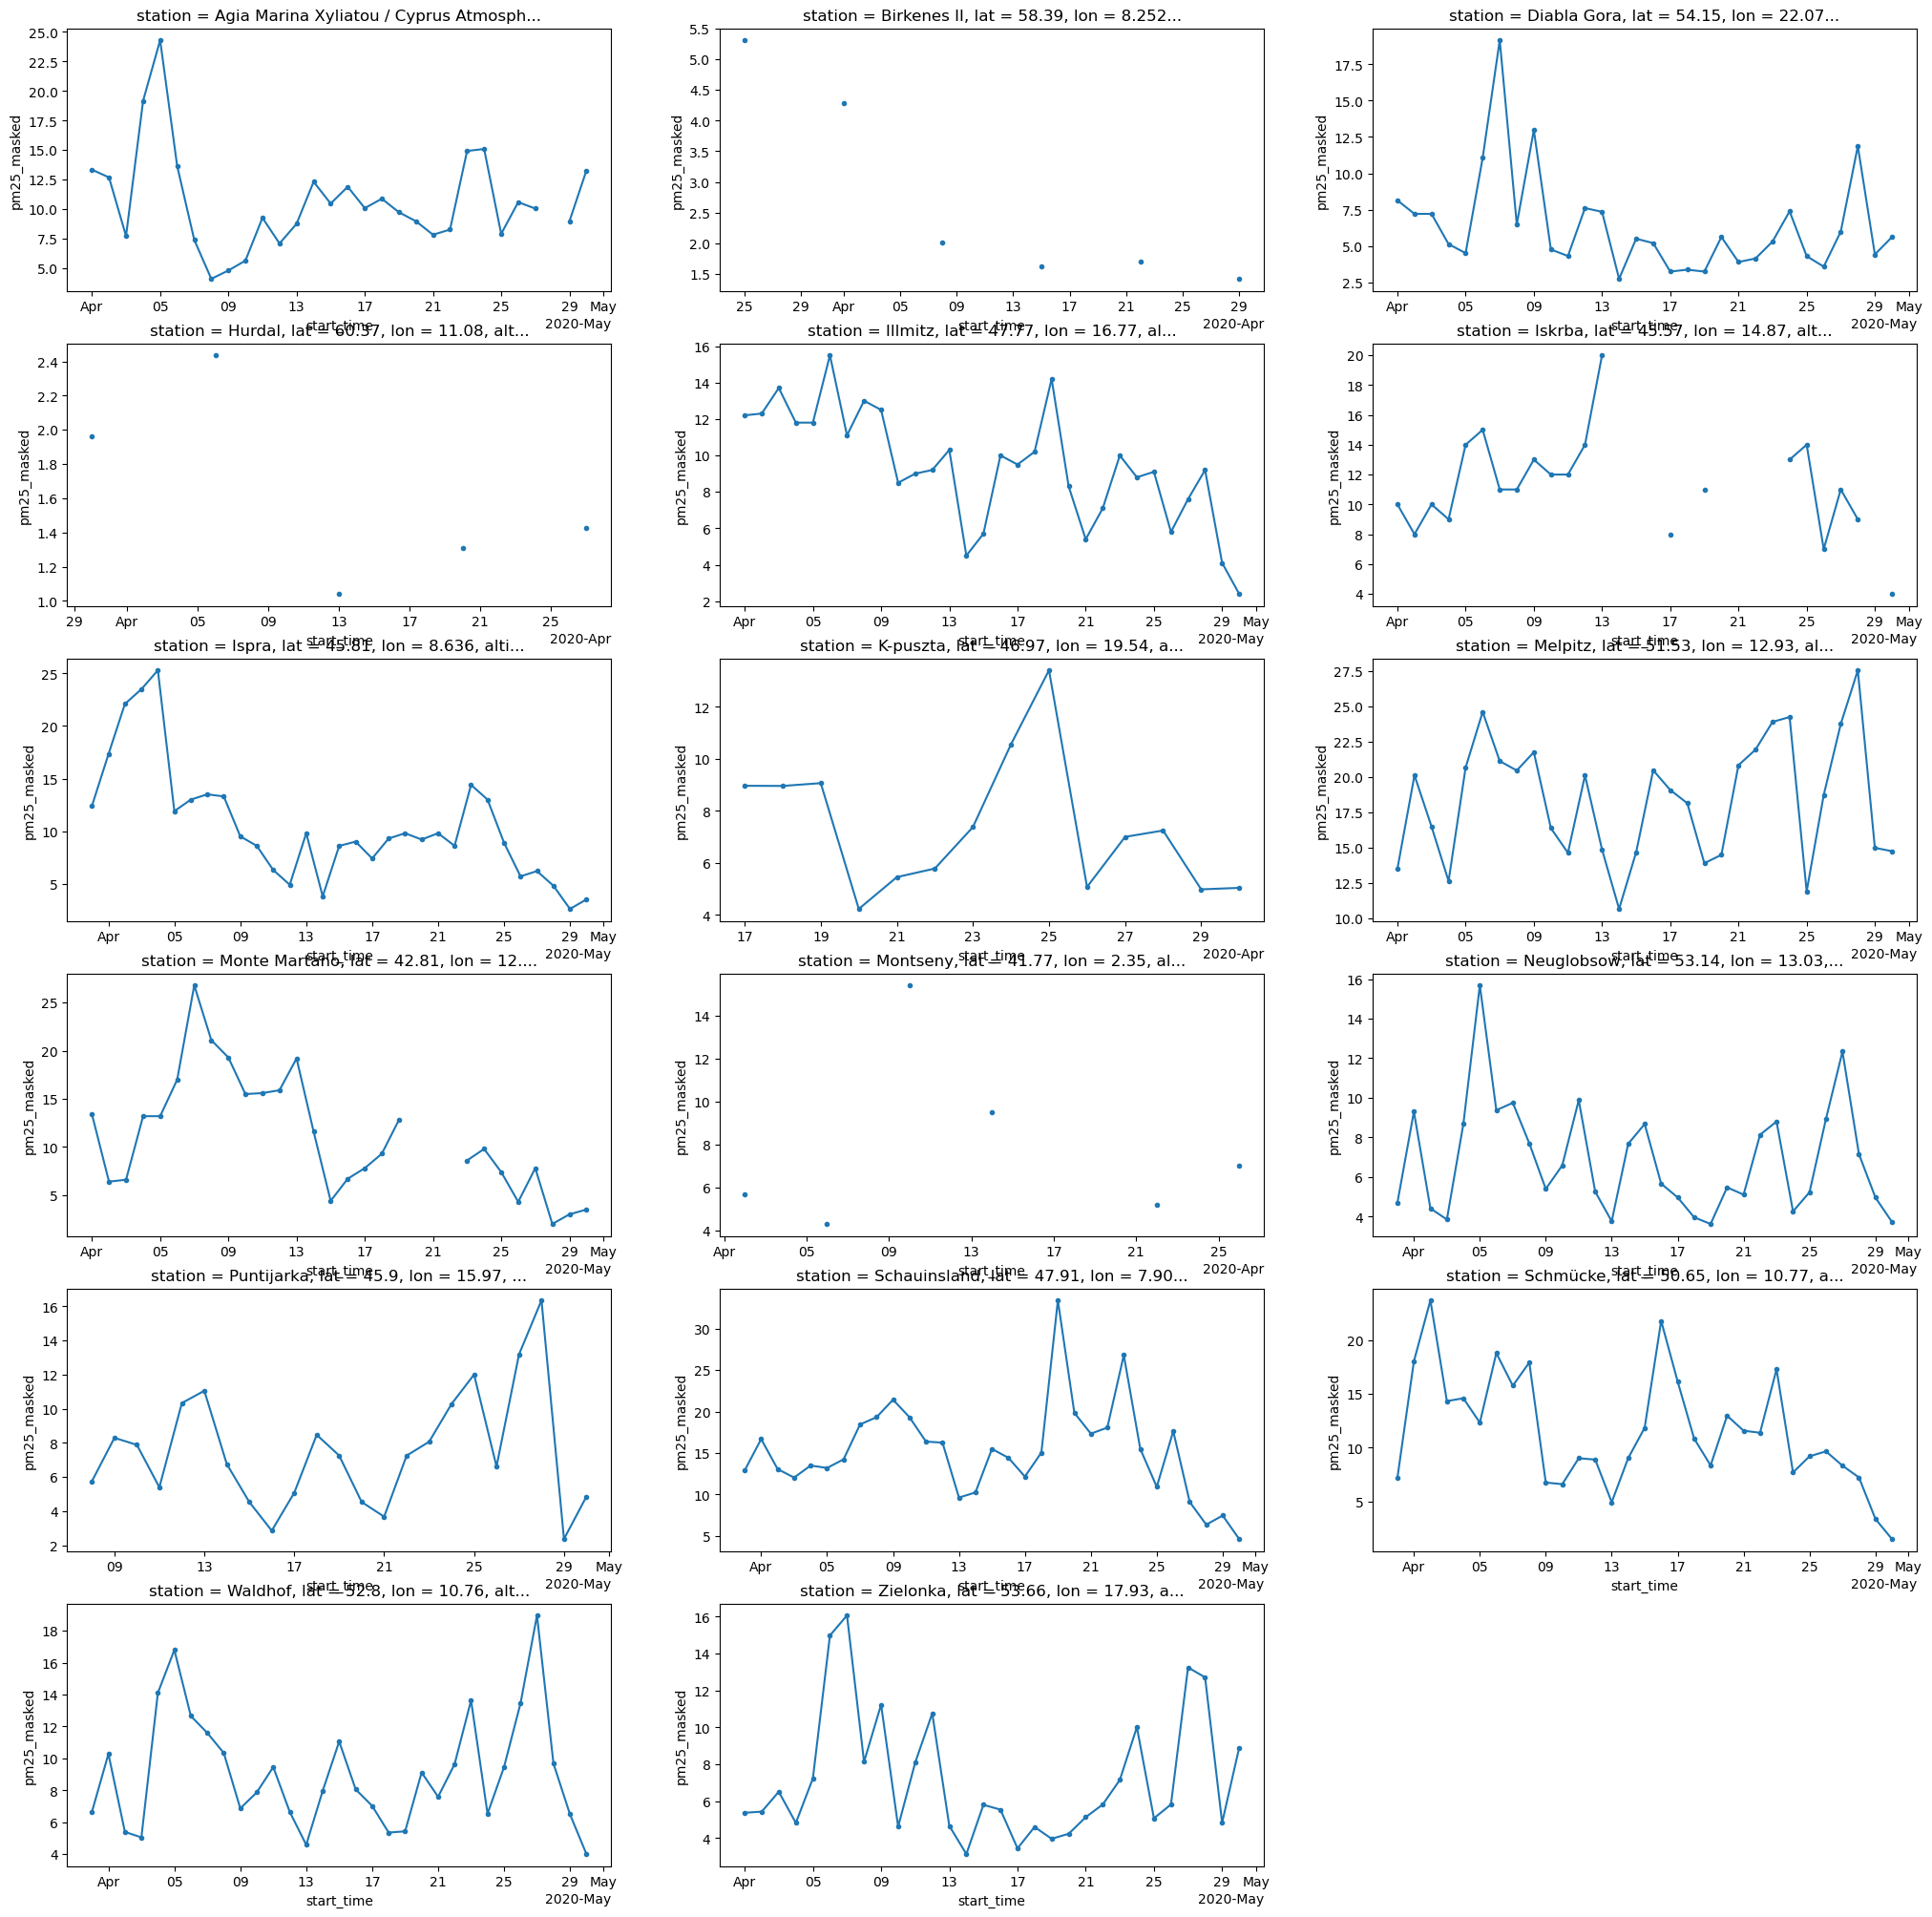

In [22]:
fig, axes = plt.subplots(6, 3, figsize=(25,25))
for i in range(len(stations_to_keep)):
    st = stations_to_keep[i]
    ax = axes.flatten()[i]
    emep_subset.sel(station=st).pm25_masked.plot(marker=".", ax=ax)
for ax in axes.flatten()[len(stations_to_keep):]:
    ax.axis("off")

## save

In [23]:
filename = "/mnt/data/emep/emep_pm25_processed.nc"
emep_subset.to_netcdf(filename)